In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
import os
import random
from geopy.distance import geodesic
from plotly import express as px
import json 
import plotly.graph_objects as go
import geopandas as gpd
import os


## Plotting helper functions

In [2]:
# Function to extract coordinates from GeoJSON and draw boundaries
def add_geojson_boundaries(fig, geojson):
    for feature in geojson['features']:
        geometry = feature['geometry']
        coords = []
        
        if geometry['type'] == 'Polygon':
            coords = geometry['coordinates'][0]  # Outer boundary
        elif geometry['type'] == 'MultiPolygon':
            for polygon in geometry['coordinates']:
                coords.extend(polygon[0])
                coords.append([None, None])  # Separator for discontinuous lines
        
        
        if coords:
            lons, lats = zip(*coords)
            fig.add_trace(go.Scattergeo(
                lon=lons,
                lat=lats,
                mode='lines',
                line=dict(width=1, color='lightblue'),
                showlegend=False,
                hoverinfo='skip'
            ))


# National population (by state)

In [ ]:
# downlaoded from : https://en.www.inegi.org.mx/programas/ccpv/2020/#open_data
mexico_states = {
    "Aguascalientes": "01", "Baja California": "02", "Baja California Sur": "03","Campeche": "04", "Coahuila de Zaragoza": "05","Colima": "06", "Chiapas": "07","Chihuahua": "08","Ciudad de México": "09","Durango": "10","Guanajuato": "11","Guerrero": "12","Hidalgo": "13","Jalisco": "14","México": "15", "Michoacán de Ocampo": "16", "Morelos": "17", "Nayarit": "18", "Nuevo León": "19", "Oaxaca": "20","Puebla": "21", "Querétaro": "22", "Quintana Roo": "23", "San Luis Potosí": "24", "Sinaloa": "25", "Sonora": "26", "Tabasco": "27", "Tamaulipas": "28", "Tlaxcala": "29", "Veracruz de Ignacio de la Llave": "30", "Yucatán": "31", "Zacatecas": "32"
}


one_state = False
first_rows = []
if one_state:
    state = 'San Luis Potosí'
    filename = f'../Datos Nacionales/POBLACION/ITER_{mexico_states[state]}XLSX20.xlsx'
    pop_df = pd.read_excel(filename)

elif os.path.exists('../Datos Nacionales/POBLACION/pop_by_state.xlsx'):
    gdf = gpd.read_file('../Datos SLP/shapefiles/mexico_by_estado.json')
    gdf = gdf.to_crs(6372)
    gdf['centroid'] = gdf['geometry'].centroid
    
    pop_df = pd.read_excel('../Datos Nacionales/POBLACION/pop_by_state.xlsx')

else:
    # takes a few minutes to run
    for state, code in mexico_states.items():
        df = pd.read_excel(f'../Datos Nacionales/POBLACION/ITER_{mexico_states[state]}XLSX20.xlsx')
        fr = df.iloc[0]
        first_rows.append(fr)
    pop_df = pd.DataFrame(first_rows)
    pop_df = pop_df.reset_index(drop=True)
    pop_df = pop_df.set_index('NOM_ENT', drop=False)
    
    gdf = gpd.read_file('../Datos SLP/shapefiles/mexico_by_estado.json')
    # gdf = gdf.to_crs(6372)
    gdf['centroid'] = gdf['geometry'].centroid
    gdf = gdf.set_index('name', drop='False')
    
    pop_df['X'] = gdf['centroid'].x
    pop_df['Y'] = gdf['centroid'].y
    pop_df.to_excel('../Datos Nacionales/POBLACION/pop_by_state.xlsx')
    
    

print(pop_df.head())

# Combined contaminant data

In [5]:
contaminants_xl = pd.ExcelFile('../Datos Nacionales/BaseNacional-Ladr-Agua-Mina.xlsx')
# ladrilleras 
cont_ladr = pd.read_excel(contaminants_xl,'Ladrilleras')
cont_ladr = cont_ladr.rename(columns={'x': 'X', 'y':'Y', 'municipio': 'MUNICIPIO'})
cont_ladr['tipo'] = 'ladrillera'

# mines
cont_minas = pd.read_excel(contaminants_xl,'Minas')
cont_minas['tipo'] = 'mina'

# water
cont_minas = cont_minas.rename(columns={'Municipio': 'MUNICIPIO'})
cont_agua = pd.read_excel(contaminants_xl,'Agua')
cont_agua['tipo'] = 'agua'

# has null values; replacing with 0s for now
cols_to_replace = ['Acrilonitrilo', 'Benceno', 'Arsenico_Total', 'Cadmio_Total', 'Arsenico_Soluble', 'Cadmio_Soluble','metales', 'elementos']

# super dataframe
contaminants_all = pd.concat([cont_ladr, cont_agua, cont_minas], ignore_index=True)
contaminants_all[cols_to_replace] = contaminants_all[cols_to_replace].fillna(0)



In [6]:
# downlaoded from https://github.com/PhantomInsights/mexico-geojson/blob/main/2023/%60mexico.zip
# state-level boundaries
with open('../Datos SLP/shapefiles/mexico_by_estado.json', 'r') as f:
    mex_geojson = json.load(f)

In [ ]:
'''
creates a scatter plot of all the contanimants we have, colored by type (ladrillera, mine, water)
'''

# Create figure
fig = go.Figure()

# Add GeoJSON boundaries
add_geojson_boundaries(fig, mex_geojson)

# how to color different scatter points
color_col = 'tipo'
# Add scatter points
for eff in contaminants_all[color_col].unique():
    mun_data = contaminants_all[contaminants_all[color_col] == eff]
    # print(mun_data)
    fig.add_trace(go.Scattergeo(
        lon=mun_data['X'],
        lat=mun_data['Y'],
        text=[mun_data['MUNICIPIO']],
        name=eff,
        mode='markers',
        marker=dict(size=8), 
        opacity=0.5
    ))

fig.update_geos(
    fitbounds="locations",
    visible=True
)

fig.update_layout(
    height=600,
    showlegend=True,
    title_text='Emissions by state'
)


fig.update_layout(title_text='Mapa de ladrilleras, minas, y agua')
fig.show()
# uncomment to save as html
# fig.write_html('point_sources.html')

# Computing effects

In [ ]:
import pdb

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Calculate haversine distance in km (vectorized)
    lat/lon in degrees
    """
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c



##############################

def pollutant_effect(pollutant, location, pol_name='ALC_mg/L', lon_name = 'X', lat_name = 'Y', pop_name = 'POBTOT'):
    # pdb.set_trace()
    
    pop = location[pop_name]
    distance = haversine_vectorized(location[lat_name], location[lon_name], pollutant[lat_name], pollutant[lon_name])
    pol_amt = pollutant[pol_name]
    if isinstance(pol_amt, str):
        if pol_amt[0] in ['>', '<']:
            # if a measurement is "<0.00065", take the measurement as 0.00065, for example
            # same with "">20", takes as 20
            pol_amt = float(pol_amt[1:])
        else:
            pol_amt = float(pol_amt)

   
    
    # TODO: revisit if we want to make this more complex
    return pop * pol_amt / distance



pollutant_list = ['Acrilonitrilo']#, 'Benceno', 'Arsenico_Total', 'Cadmio_Total', 'Arsenico_Soluble', 'Cadmio_Soluble']


# empty dataframe where we will store a "score" per pollutant effect
effects_df = pd.DataFrame()
effects_df['NOM_ENT'] = pop_df['NOM_ENT']


for pol in pollutant_list:
    effects_df[pol] = 0.0

# note: takes about 30s per contaminant (on my laptop)
for pol in pollutant_list:
    for i, location in pop_df.iterrows():
        
        effect = contaminants_all.apply(lambda pollutant: pollutant_effect(pollutant, location, pol_name = pol), axis=1)

        effects_df.loc[i, pol] = effect.sum()
        print(f'Effect of {pol} on {location["NOM_ENT"]} is {effect.sum()}')
        

        
# TODO: @Lynda: would be good to run this on the full set, and save the dataframe as an excel file, like the population dataframe above

# Heatmap of effects of pollutants

In [ ]:
# might be helpful to visualize log scale, or might be more confusing
# effects_df['log_Ac'] = np.log(effects_df['Acrilonitrilo'])
fig = go.Figure()
pollutant = 'Acrilonitrilo' # 'Acrilonitrilo', 'Benceno', etc.
fig = px.choropleth(
    effects_df, 
    geojson=mex_geojson, 
    color=pollutant, 
    locations='NOM_ENT',  # column in state_pop_df that matches GeoJSON features
    featureidkey='properties.name',  # key in GeoJSON properties
    color_continuous_scale='Greens'
)
fig.update_geos(
    fitbounds="locations"
)
fig.update_layout(
    height=600,
    showlegend=True, title_text=f'Effect of {pollutant}'
)
fig.show()


# Heatmap of population

In [ ]:

fig = go.Figure()
fig = px.choropleth(
    pop_df, 
    geojson=mex_geojson, 
    color='POBTOT', 
    locations='NOM_ENT',  # column in state_pop_df that matches GeoJSON features
    featureidkey='properties.name',  # key in GeoJSON properties
    color_continuous_scale='Greens'
)
fig.update_geos(
    fitbounds="locations"
)
fig.update_layout(
    height=600,
    showlegend=True, title_text='Population heatmap'
)
fig.show()


# National mortality

In [ ]:
# data source: https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=mortalidad_Mortalidad_05_6a897e74-26b8-44de-8994-d9c46acdb64c
# data is specifically breast cancer mortality

# save national mortality as a dataframe
nat_mort = pd.read_excel('../Datos Nacionales/MORTALIDAD/Mortalidad_05.xlsx', skiprows=6)
nat_mort = nat_mort.set_index('Entidad federativa', drop=False)
nat_mort = nat_mort.rename(columns={'Entidad federativa': 'NOM_ENT'})

# Grupo quinquenal de edad is the age groups
# currently taking total population, but could also take e.g., "40 a 44 años", or a sum of age groups
nat_mort_state_totals = nat_mort[nat_mort['Grupo quinquenal de edad'] == 'Total'].drop('Total')
print(nat_mort_state_totals.columns)


In [ ]:
# heatmap of breast cancer mortalities
# TODO: @Lynda if you can modify this to be mortality per capita, this might be a helpful visualization.
# might need to be careful to align indices ; currently pop_df indices are the name of the state in NOM_ENT
fig = go.Figure()
fig = px.choropleth(
    nat_mort_state_totals, 
    geojson=mex_geojson, 
    color='2024', 
    locations='NOM_ENT',  # column in state_pop_df that matches GeoJSON features
    featureidkey='properties.name',  # key in GeoJSON properties
    color_continuous_scale='Greens'
)
fig.update_geos(
    fitbounds="locations"
)
fig.update_layout(
    height=600,
    showlegend=True, title_text='Mortality heatmap'
)
fig.show()

# Regression on mortality

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# TODO: @Lynda: change y to be mortality-per-capita
X = effects_df.set_index('NOM_ENT', drop=True)
y = nat_mort_state_totals.drop(['Extranjero', 'No especificado'])['2024']
model = LinearRegression().fit(X,y)
print(model.coef_)
print(model.intercept_)
print(f'r^2 score: {r2_score(model.predict(X), y)}')

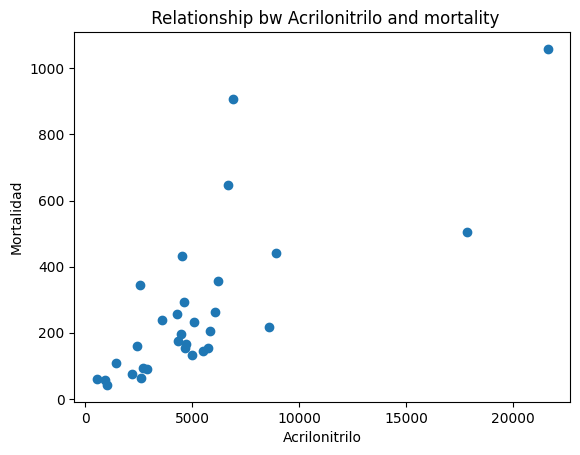

In [13]:
# generatting a scatter plot between pollutant scores and mortality
for pol in pollutant_list:
    plt.title(f' Relationship bw {pol} and mortality')
    plt.xlabel(pol)
    plt.ylabel("Mortalidad")
    plt.scatter(X[pol], y)
    plt.show()